# xNES–CMA-ES workbench

Quick experiments on translated objectives, with random rotations for ellipsoid/cigar and the original positive half-normal noise model. Edit the settings below freely.

Both methods intentionally share a population size here; the benchmark notebook uses each method's native default. Helpers share evaluation accounting, diagnostics, and stop handling with the benchmark. Curves show clean fitness at the current mean against **objective calls**, end at termination, and mark early stops with a cross.

This is an exploratory view, not held-out evidence. The benchmark notebook provides broader landscapes, noise models, paired comparisons, and failure reports.

In [1]:
from pathlib import Path
import sys
from collections import Counter

ROOT = Path.cwd() if (Path.cwd() / "leitwerk").is_dir() else Path.cwd().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np
from tqdm.notebook import tqdm
from leitwerk import XNESLearningRates
from leitwerk.xnes import _default_sample_count
from benchmarks.problems import Problem, translated_objective, seed_for
from benchmarks.runner import run_trial
from benchmarks.reporting import run_table

In [2]:
# Main knobs.
DIMENSION = 30
MAX_ITERATIONS = 300
NUM_TRIALS = 3
MASTER_SEED = 1234

# Problem setup. Both optimizers see the same start state and the same transformed objective distribution.
INITIAL_SIGMA = 1.0
START_VALUE = 0.0
LOG_EPS = 1e-16
NOISE_SCALE = 1e-3
OFFSET_SCALE = 1.0
FUNCTION_NAMES = ("sphere", "ackley", "rosenbrock", "ellipsoid", "cigar")
ROTATED_FUNCTIONS = frozenset({"ellipsoid", "cigar"})

# XNES settings
XNES_LEARNING_RATES = XNESLearningRates(
    eta_mean=1.0,
    eta_scale_global=0.5,
    eta_scale_shape=0.25,
)

batch_SIZE = _default_sample_count(None, DIMENSION)
X0 = np.full(DIMENSION, START_VALUE, dtype=float)
TRIAL_SEEDS = MASTER_SEED + np.arange(NUM_TRIALS, dtype=int)

print(
    {
        'dimension': DIMENSION,
        'batch_size': batch_SIZE,
        'max_iterations': MAX_ITERATIONS,
        'num_trials': NUM_TRIALS,
        'initial_sigma': INITIAL_SIGMA,
        'noise_scale': NOISE_SCALE,
        'offset_scale': OFFSET_SCALE,
        'functions': FUNCTION_NAMES,
        'rotated_functions': sorted(ROTATED_FUNCTIONS),
    }
)

{'dimension': 30, 'batch_size': 14, 'max_iterations': 300, 'num_trials': 3, 'initial_sigma': 1.0, 'noise_scale': 0.001, 'offset_scale': 1.0, 'functions': ('sphere', 'ackley', 'rosenbrock', 'ellipsoid', 'cigar'), 'rotated_functions': ['cigar', 'ellipsoid']}


In [3]:
def make_noisy_objective(function_name, dim, trial_seed):
    # Retain the workbench's translated/rotated half-normal experiment.
    case_seed = np.random.SeedSequence([MASTER_SEED, FUNCTION_NAMES.index(function_name), dim, int(trial_seed)])
    clean, noisy, offset, rotated = translated_objective(
        function_name, dim, case_seed, OFFSET_SCALE, NOISE_SCALE
    )
    problem = Problem(function_name, lambda x: float(clean(x)[0]), X0.copy())
    return problem, lambda x: float(noisy(x)[0]), {"rotated": rotated, "offset_norm": float(np.linalg.norm(offset))}

In [4]:
def run_suite(function_name):
    results = []
    for trial_seed in tqdm(TRIAL_SEEDS, desc=function_name):
        for algorithm_index, algorithm in enumerate(("xnes", "cma")):
            problem, observed, metadata = make_noisy_objective(function_name, DIMENSION, int(trial_seed))
            result = run_trial(
                problem=problem,
                algorithm=algorithm,
                budget=MAX_ITERATIONS * batch_SIZE,
                optimizer_seed=seed_for(MASTER_SEED, FUNCTION_NAMES.index(function_name), int(trial_seed), algorithm_index),
                noise_seed=int(trial_seed),
                scale=INITIAL_SIGMA,
                population=batch_SIZE,  # Intentional equal-population experiment; benchmark uses native defaults.
                learning_rates=XNES_LEARNING_RATES,
                observation=observed,
            )
            result.update(metadata)
            result["trial_seed"] = int(trial_seed)
            results.append(result)
    return results

In [5]:
results_by_function = {name: run_suite(name) for name in FUNCTION_NAMES}
for name, runs in results_by_function.items():
    print(name, {algorithm: dict(Counter(r["kind"] + ": " + r["reason"] for r in runs if r["algorithm"] == algorithm))
                 for algorithm in ("xnes", "cma")})

sphere:   0%|          | 0/3 [00:00<?, ?it/s]

ackley:   0%|          | 0/3 [00:00<?, ?it/s]

rosenbrock:   0%|          | 0/3 [00:00<?, ?it/s]

ellipsoid:   0%|          | 0/3 [00:00<?, ?it/s]

cigar:   0%|          | 0/3 [00:00<?, ?it/s]

sphere {'xnes': {'budget: Insufficient budget for another complete population': 3}, 'cma': {'budget: Insufficient budget for another complete population': 3}}
ackley {'xnes': {'budget: Insufficient budget for another complete population': 3}, 'cma': {'budget: Insufficient budget for another complete population': 3}}
rosenbrock {'xnes': {'budget: Insufficient budget for another complete population': 3}, 'cma': {'budget: Insufficient budget for another complete population': 3}}
ellipsoid {'xnes': {'budget: Insufficient budget for another complete population': 3}, 'cma': {'budget: Insufficient budget for another complete population': 3}}
cigar {'xnes': {'budget: Insufficient budget for another complete population': 3}, 'cma': {'budget: Insufficient budget for another complete population': 3}}


In [6]:
summary = run_table([run for runs in results_by_function.values() for run in runs])
summary[["problem", "algorithm", "trial_seed", "evaluations", "kind", "reason",
         "final_mean_gap", "final_axis_ratio", "warning_count"]]

,problem,algorithm,trial_seed,evaluations,kind,reason,final_mean_gap,final_axis_ratio,warning_count
0,sphere,xnes,1234,4200,budget,Insufficient budget for another complete popul...,0.000321,1.422862,0
1,sphere,cma,1234,4200,budget,Insufficient budget for another complete popul...,0.000548,2.268008,1
2,sphere,xnes,1235,4200,budget,Insufficient budget for another complete popul...,0.000299,1.426835,0
3,sphere,cma,1235,4200,budget,Insufficient budget for another complete popul...,0.000378,2.373253,1
4,sphere,xnes,1236,4200,budget,Insufficient budget for another complete popul...,0.000269,1.426625,0
5,sphere,cma,1236,4200,budget,Insufficient budget for another complete popul...,0.000611,2.227009,1
6,ackley,xnes,1234,4200,budget,Insufficient budget for another complete popul...,0.000962,1.403934,0
7,ackley,cma,1234,4200,budget,Insufficient budget for another complete popul...,0.001503,2.179648,1
8,ackley,xnes,1235,4200,budget,Insufficient budget for another complete popul...,0.000923,1.370403,0
9,ackley,cma,1235,4200,budget,Insufficient budget for another complete popul...,0.001253,2.117587,1


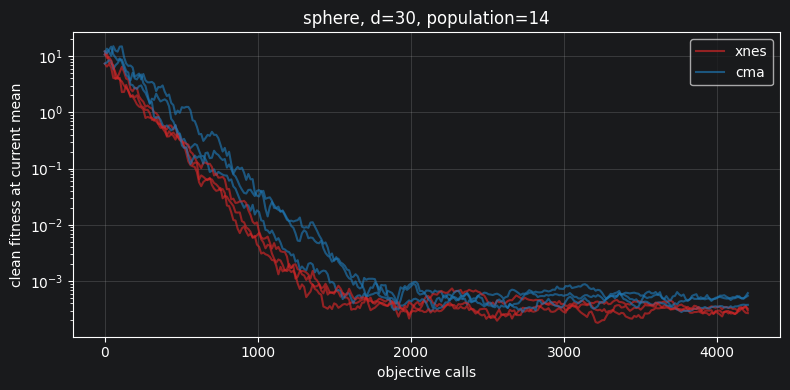

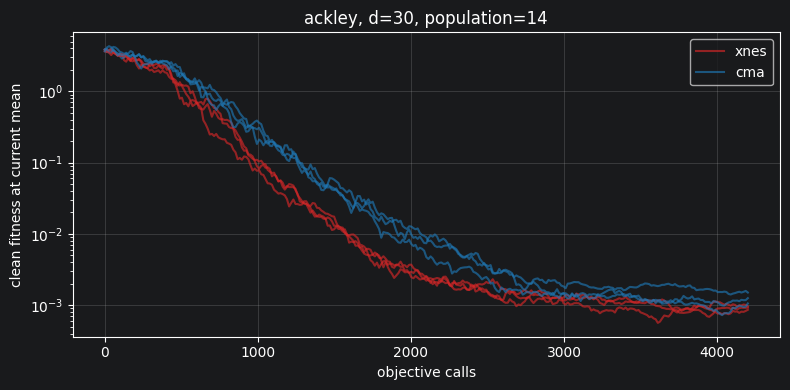

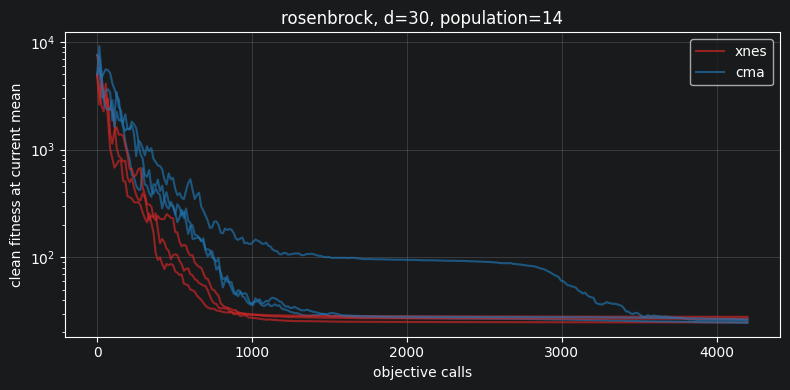

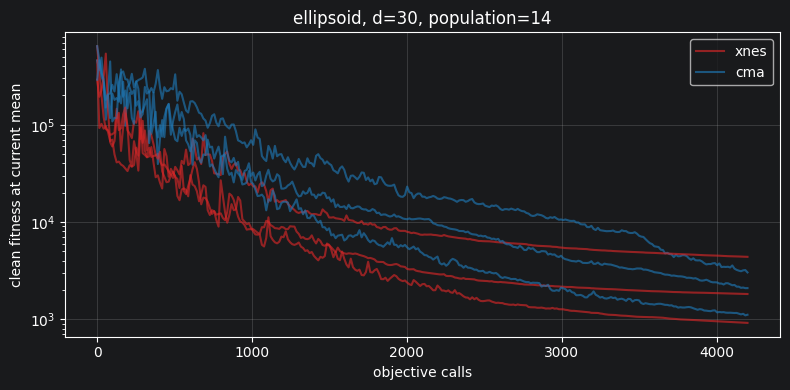

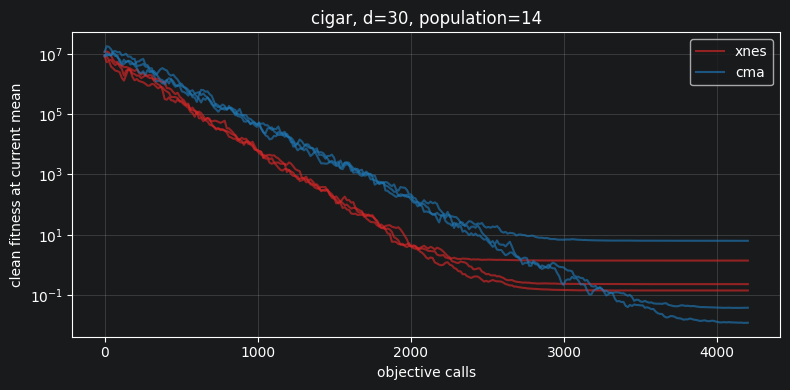

In [7]:
palette = {"xnes": "tab:red", "cma": "tab:blue"}
for name, runs in results_by_function.items():
    fig, ax = plt.subplots(figsize=(8, 4))
    for index, run in enumerate(runs):
        history = run["trajectory"]
        ax.plot(
            [p["evaluations"] for p in history],
            [max(p["mean_gap"], LOG_EPS) for p in history],
            color=palette[run["algorithm"]], alpha=0.65,
            label=run["algorithm"] if index < 2 else None,
        )
        if history and run["kind"] != "budget":
            point = history[-1]
            ax.scatter(point["evaluations"], max(point["mean_gap"], LOG_EPS),
                       marker="x", color=palette[run["algorithm"]])
    ax.set(yscale="log", xlabel="objective calls", ylabel="clean fitness at current mean",
           title=f"{name}, d={DIMENSION}, population={batch_SIZE}")
    ax.grid(alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()